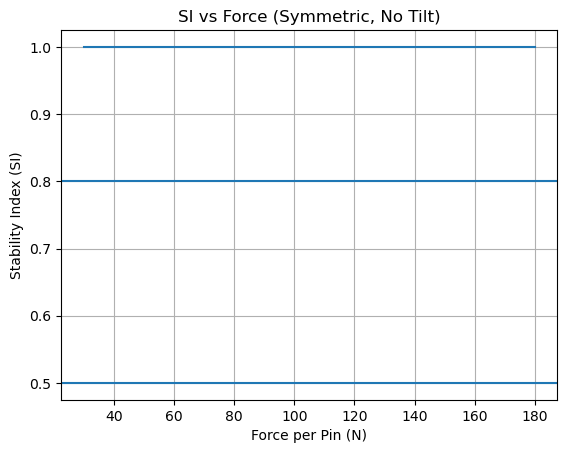

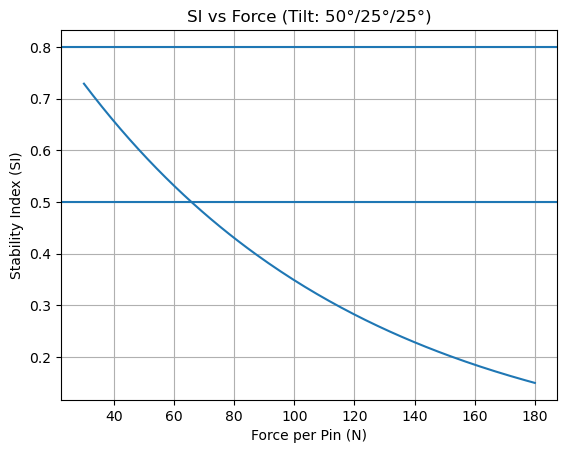

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_clamp_basic(forces_N, phis_deg, skull_geom=None,
                         k_depth=0.04, Mcrit=50.0, M_slip=30.0, dcrit=1.0):
    if skull_geom is None:
        skull_geom = {'type': 'sphere', 'R': 85.0}
    phis = np.deg2rad(phis_deg)
    if skull_geom['type'] == 'ellipsoid':
        a, b = skull_geom['a'], skull_geom['b']
        r = np.stack([a*np.cos(phis), b*np.sin(phis), np.zeros_like(phis)], axis=1)
    else:
        R = skull_geom['R']
        r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    Mz = np.cross(r, F_vec)[:,2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    return SI

def evaluate_clamp_extended(forces_N, phis_deg, tilts_deg,
                            skull_geom=None, k_depth=0.04,
                            Mcrit=50.0, M_slip=30.0, dcrit=1.0):
    if skull_geom is None:
        skull_geom = {'type': 'sphere', 'R': 85.0}
    phis = np.deg2rad(phis_deg)
    tilts = np.deg2rad(tilts_deg)
    if skull_geom['type'] == 'ellipsoid':
        a,b = skull_geom['a'], skull_geom['b']
        r = np.stack([a*np.cos(phis), b*np.sin(phis), np.zeros_like(phis)], axis=1)
    else:
        R = skull_geom['R']
        r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    ez = np.array([0.0,0.0,1.0])
    forces = np.asarray(forces_N, float)
    F_vec = np.array([
        -forces[i] * ( -np.cos(tilts[i]) * r_hat[i] + np.sin(tilts[i]) * ez )
        for i in range(3)
    ])
    Mz = np.cross(r, F_vec)[:,2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    return SI

# Force vs Stability plots
forces = np.linspace(30, 180, 150)
phis = [0, 120, 240]
tilts_basic = [0, 0, 0]
tilts_extended = [50, 25, 25]

# Compute SI arrays
SI_basic = [evaluate_clamp_basic([F, F, F], phis) for F in forces]
SI_ext = [evaluate_clamp_extended([F, F, F], phis, tilts_extended) for F in forces]

# Plot 1: Basic symmetric
plt.figure()
plt.plot(forces, SI_basic)
plt.axhline(0.8)
plt.axhline(0.5)
plt.xlabel("Force per Pin (N)")
plt.ylabel("Stability Index (SI)")
plt.title("SI vs Force (Symmetric, No Tilt)")
plt.grid(True)
plt.show()

# Plot 2: Extended tilt
plt.figure()
plt.plot(forces, SI_ext)
plt.axhline(0.8)
plt.axhline(0.5)
plt.xlabel("Force per Pin (N)")
plt.ylabel("Stability Index (SI)")
plt.title("SI vs Force (Tilt: 50°/25°/25°)")
plt.grid(True)
plt.show()


In [4]:
# # skull_clamp.py
# """
# Comprehensive skull‐clamp stability module.

# Provides:
#   - evaluate_clamp_basic(): radial forces only
#   - evaluate_clamp_extended(): includes tilt
#   - plot_clamp(): visualize a single configuration

# Usage:
#   python skull_clamp.py
# """

# import numpy as np
# import matplotlib.pyplot as plt

# def evaluate_clamp_basic(forces_N, phis_deg, skull_geom=None,
#                          k_depth=0.04, Mcrit=50.0, M_slip=30.0, dcrit=1.0):
#     """
#     Basic stability evaluation (radial forces only).
#     Inputs:
#       forces_N: list of 3 floats [F1, F2, F3] in N
#       phis_deg: list of 3 floats [φ1, φ2, φ3] in degrees (azimuth around skull)
#       skull_geom: dict, optional:
#           {'type':'sphere','R':radius_mm} or
#           {'type':'ellipsoid','a':x_radius_mm,'b':y_radius_mm}
#     Returns dict with:
#       'Mz'           : net torque about z-axis (N·mm)
#       'depths_mm'    : array of 3 penetration‐depth proxies (mm)
#       'depth_spread' : max(depths) - min(depths) (mm)
#       'SI'           : stability index (0…1)
#       'status'       : 'stabil','grenzwertig','kritisch'
#       'slip_risk'    : True if |Mz| > M_slip
#     """
#     # Default geometry
#     if skull_geom is None:
#         skull_geom = {'type':'sphere','R':85.0}
#     # Rad angles
#     phis = np.deg2rad(phis_deg)
#     # Pin positions
#     if skull_geom['type']=='ellipsoid':
#         a,b = skull_geom['a'], skull_geom['b']
#         r = np.stack([a*np.cos(phis), b*np.sin(phis), np.zeros_like(phis)], axis=1)
#     else:
#         R = skull_geom['R']
#         r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
#     # Normals
#     r_hat = r / np.linalg.norm(r, axis=1)[:,None]
#     forces = np.asarray(forces_N, float)
#     # Force vectors (radial)
#     F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
#     # Torque
#     Mz = np.cross(r, F_vec)[:,2].sum()
#     # Depth proxies
#     depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
#     delta_d = depths.ptp()
#     # Stability Index
#     SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
#     if SI >= 0.8:
#         status = 'stabil'
#     elif SI >= 0.5:
#         status = 'grenzwertig'
#     else:
#         status = 'kritisch'
#     slip_risk = abs(Mz) > M_slip
#     return {
#         'Mz': Mz,
#         'depths_mm': depths,
#         'depth_spread': delta_d,
#         'SI': SI,
#         'status': status,
#         'slip_risk': slip_risk
#     }

# def evaluate_clamp_extended(forces_N, phis_deg, tilts_deg,
#                             skull_geom=None, k_depth=0.04,
#                             Mcrit=50.0, M_slip=30.0, dcrit=1.0):
#     """
#     Extended stability evaluation (radial + tilt).
#     tilts_deg: list of 3 floats [α1, α2, α3] in degrees (tilt from radial)
#     """
#     if skull_geom is None:
#         skull_geom = {'type':'sphere','R':85.0}
#     phis = np.deg2rad(phis_deg)
#     tilts = np.deg2rad(tilts_deg)
#     # Positions
#     if skull_geom['type']=='ellipsoid':
#         a,b = skull_geom['a'], skull_geom['b']
#         r = np.stack([a*np.cos(phis), b*np.sin(phis), np.zeros_like(phis)], axis=1)
#     else:
#         R = skull_geom['R']
#         r = np.stack([R*np.cos(phis), R*np.sin(phis), np.zeros_like(phis)], axis=1)
#     r_hat = r / np.linalg.norm(r, axis=1)[:,None]
#     ez = np.array([0.0,0.0,1.0])
#     forces = np.asarray(forces_N, float)
#     # Force with tilt
#     F_vec = np.array([
#         -forces[i] * (
#             -np.cos(tilts[i]) * r_hat[i] + np.sin(tilts[i]) * ez
#         )
#         for i in range(3)
#     ])
#     Mz = np.cross(r, F_vec)[:,2].sum()
#     depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
#     delta_d = depths.ptp()
#     SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
#     status = 'stabil' if SI>=0.8 else 'grenzwertig' if SI>=0.5 else 'kritisch'
#     slip_risk = abs(Mz)>M_slip
#     return {
#         'Mz': Mz,
#         'depths_mm': depths,
#         'depth_spread': delta_d,
#         'SI': SI,
#         'status': status,
#         'slip_risk': slip_risk
#     }

# def plot_clamp(forces, phis, tilts=None, skull_geom=None):
#     """
#     Visualize a single clamp config in top-down view.
#     """
#     if tilts is None:
#         res = evaluate_clamp_basic(forces, phis, skull_geom)
#         phis_rad = np.deg2rad(phis)
#         R = skull_geom['R'] if skull_geom else 85
#         r = np.stack([R*np.cos(phis_rad), R*np.sin(phis_rad)], axis=1)
#         F_vec = np.array([-forces[i] * (r[i]/np.linalg.norm(r[i])) for i in range(3)])
#     else:
#         res = evaluate_clamp_extended(forces, phis, tilts, skull_geom)
#         # reuse F_vec from extended
#         phis_rad = np.deg2rad(phis)
#         R = skull_geom['R'] if skull_geom else 85
#         r = np.stack([R*np.cos(phis_rad), R*np.sin(phis_rad)], axis=1)
#         # Recompute radial component for arrow direction
#         F_vec = np.array([-forces[i] * (r[i]/np.linalg.norm(r[i])) for i in range(3)])
#     # Plot
#     fig, ax = plt.subplots(figsize=(5,5))
#     circle = plt.Circle((0,0), R, fill=False, linestyle='--', color='gray')
#     ax.add_patch(circle)
#     for i in range(3):
#         ax.plot(r[i,0], r[i,1], 'ko')
#         ax.arrow(r[i,0], r[i,1], F_vec[i,0]*0.05, F_vec[i,1]*0.05,
#                  head_width=2, length_includes_head=True, color='C1')
#     ax.set_aspect('equal')
#     ax.set_xlim(-R*1.3, R*1.3)
#     ax.set_ylim(-R*1.3, R*1.3)
#     ax.set_title(f"SI={res['SI']:.2f} ({res['status']}), Mz={res['Mz']:.1f}")
#     ax.set_xlabel("X (mm)")
#     ax.set_ylabel("Y (mm)")
#     ax.grid(True)
#     plt.show()

# if __name__ == "__main__":
#     # Example: symmetric basic
#     plot_clamp([100,100,100], [0,120,240])
#     # Example: extended tilt
#     plot_clamp([100,100,100], [0,120,240], tilts=[50,25,25])

# # skull_clamp_heatmap.py
# """
# Generate heatmaps of stability vs. parameter sweeps.

# Depends on skull_clamp.py being in the same folder.
# Usage:
#   python skull_clamp_heatmap.py
# """

# import numpy as np
# import matplotlib.pyplot as plt
# from skull_clamp import evaluate_clamp_basic

# def heatmap_force_vs_separation():
#     """
#     Sweep equal force (50–150 N) and rear-pin separation (60°–180°).
#     """
#     forces = np.linspace(50,150,120)
#     seps = np.linspace(60,180,120)
#     SI = np.zeros((len(forces), len(seps)))
#     for i,F in enumerate(forces):
#         for j,sep in enumerate(seps):
#             angles = [0,(360-sep)/2,(360+sep)/2]
#             SI[i,j] = evaluate_clamp_basic([F,F,F], angles)['SI']
#     fig, ax = plt.subplots(figsize=(8,6))
#     im = ax.imshow(SI, origin='lower',
#                    extent=[seps[0],seps[-1],forces[0],forces[-1]],
#                    aspect='auto', cmap='viridis')
#     fig.colorbar(im, ax=ax, label="Stability Index (SI)")
#     ax.set_xlabel("Rear‐Pin Separation (°)")
#     ax.set_ylabel("Force per Pin (N)")
#     ax.set_title("SI Heatmap: Force vs. Angle Separation")
#     plt.tight_layout()
#     plt.show()

# def heatmap_asym_forces():
#     """
#     Sweep force on pin A (50–150 N) vs. force on pin B (50–150 N),
#     pin C fixed at 100 N, symmetric 0°/120°/240°.
#     """
#     fA = np.linspace(50,150,120)
#     fB = np.linspace(50,150,120)
#     SI = np.zeros((len(fA),len(fB)))
#     angles = [0,120,240]
#     for i,FA in enumerate(fA):
#         for j,FB in enumerate(fB):
#             SI[j,i] = evaluate_clamp_basic([FA,FB,100], angles)['SI']
#     fig, ax = plt.subplots(figsize=(7,6))
#     im = ax.imshow(SI, origin='lower',
#                    extent=[fA[0],fA[-1],fB[0],fB[-1]],
#                    aspect='auto', cmap='plasma')
#     fig.colorbar(im, ax=ax, label="Stability Index (SI)")
#     ax.set_xlabel("Force Pin A (N)")
#     ax.set_ylabel("Force Pin B (N)")
#     ax.set_title("SI Heatmap: Asymmetric Forces (Pin C=100N)")
#     plt.tight_layout()
#     plt.show()

# if __name__ == "__main__":
#     heatmap_force_vs_separation()
#     heatmap_asym_forces()


=== Example evaluations ===
Symmetric, good force          -> SI=1.00, Mz=-0.0, Δd=0.00 mm, status=stabil


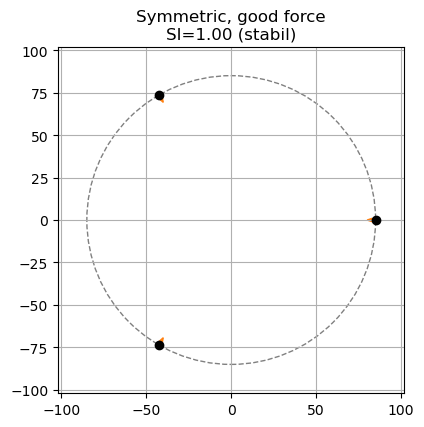

Low force, symmetric           -> SI=1.00, Mz=0.0, Δd=0.00 mm, status=stabil


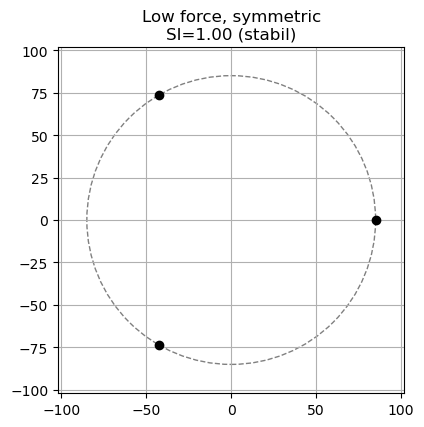

Symm. force, unbalanced angles -> SI=1.00, Mz=-0.0, Δd=0.00 mm, status=stabil


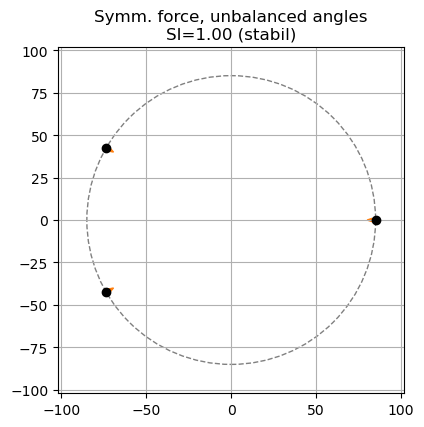

Generating heatmap: SI vs Force & Pin Separation...


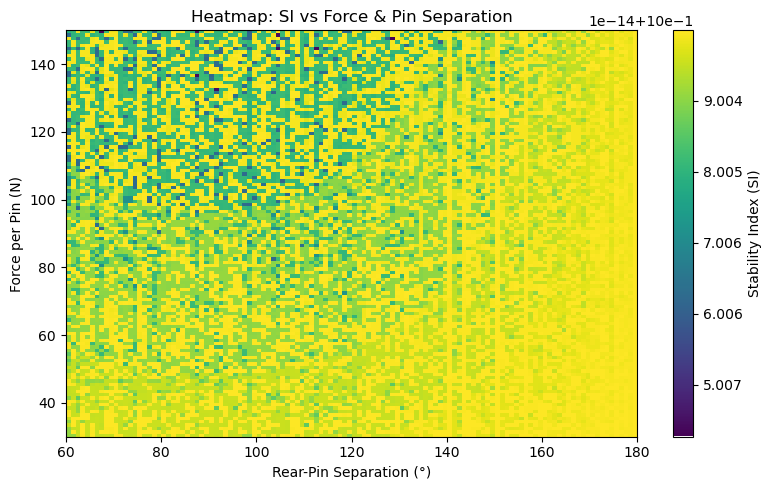

In [5]:
# skull_clamp_task.py
"""
Skull Clamp Stability Simulation (Basic Model)

This script implements:
  - A simplified 2D skull‐clamp stability model (radial forces only)
  - A function to compute stability index (SI) and classification
  - Example evaluations for 3 scenarios
  - Visualizations of each scenario
  - A heatmap of SI over Force vs. Pin Separation

Usage:
  Just run this file with Python. It will display plots and print SI results.
"""

import numpy as np
import matplotlib.pyplot as plt

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    """
    Basic 3-pin clamp stability evaluation.

    Parameters
    ----------
    forces_N : list of float
        Pin forces [F1, F2, F3] in Newtons.
    phis_deg : list of float
        Pin azimuth angles [φ1, φ2, φ3] in degrees (top-down view).
    skull_R : float
        Skull radius in mm (default 85).
    k_depth, Mcrit, dcrit : float
        Scaling constants for depth proxy, torque penalty, depth imbalance penalty.

    Returns
    -------
    dict with keys:
      - Mz: net torque about z-axis (N·mm)
      - depths: array of 3 depth proxies (mm)
      - delta_d: depth spread (mm)
      - SI: stability index (0…1)
      - status: 'stabil' / 'grenzwertig' / 'kritisch'
    """
    phis = np.deg2rad(phis_deg)
    # pin positions
    r = np.stack([skull_R*np.cos(phis),
                  skull_R*np.sin(phis),
                  np.zeros_like(phis)], axis=1)
    # radial unit vectors
    r_hat = r / np.linalg.norm(r, axis=1)[:,None]
    forces = np.asarray(forces_N, float)
    # force vectors (radial)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    # net torque Mz
    Mz = np.cross(r, F_vec)[:,2].sum()
    # depth proxies
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    # stability index
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    if SI >= 0.8: status = 'stabil'
    elif SI >= 0.5: status = 'grenzwertig'
    else: status = 'kritisch'
    return {'Mz':Mz, 'depths':depths, 'delta_d':delta_d, 'SI':SI, 'status':status}

def plot_clamp(forces, phis, title):
    """Visualize pin layout and force vectors for one scenario."""
    skull_R = 85.0
    phis_rad = np.deg2rad(phis)
    r2 = np.stack([skull_R*np.cos(phis_rad),
                   skull_R*np.sin(phis_rad)], axis=1)
    r_hat2 = r2 / np.linalg.norm(r2, axis=1)[:,None]
    # radial arrows
    F_vec2 = np.array([-forces[i]*r_hat2[i] for i in range(3)])
    # evaluate
    res = evaluate_clamp_basic(forces, phis)
    # plot
    fig, ax = plt.subplots(figsize=(4.5,4.5))
    ax.add_patch(plt.Circle((0,0), skull_R, fill=False, linestyle='--', color='gray'))
    for i in range(3):
        x,y = r2[i]
        ax.plot(x,y,'ko')
        ax.arrow(x,y, F_vec2[i,0]*0.05, F_vec2[i,1]*0.05,
                 head_width=2, length_includes_head=True, color='C1')
    ax.set_aspect('equal')
    ax.set_xlim(-skull_R*1.2, skull_R*1.2)
    ax.set_ylim(-skull_R*1.2, skull_R*1.2)
    ax.set_title(f"{title}\nSI={res['SI']:.2f} ({res['status']})")
    ax.grid(True)
    plt.show()

# Example scenarios
scenarios = [
    ([100,100,100], [0,120,240], "Symmetric, good force"),
    ([30,30,30],    [0,120,240], "Low force, symmetric"),
    ([100,100,100], [0,150,210], "Symm. force, unbalanced angles"),
]
print("=== Example evaluations ===")
for forces, phis, desc in scenarios:
    res = evaluate_clamp_basic(forces, phis)
    print(f"{desc:30s} -> SI={res['SI']:.2f}, Mz={res['Mz']:.1f}, Δd={res['delta_d']:.2f} mm, status={res['status']}")
    plot_clamp(forces, phis, desc)

# Heatmap: SI vs Force & Rear-Pin Separation
print("Generating heatmap: SI vs Force & Pin Separation...")
forces = np.linspace(30,150,120)
seps   = np.linspace(60,180,120)
SI_map = np.zeros((len(forces), len(seps)))
for i,F in enumerate(forces):
    for j,sep in enumerate(seps):
        angles = [0,(360-sep)/2,(360+sep)/2]
        SI_map[i,j] = evaluate_clamp_basic([F,F,F], angles)['SI']

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(SI_map, origin='lower',
               extent=[seps[0],seps[-1], forces[0],forces[-1]],
               aspect='auto', cmap='viridis')
plt.colorbar(im, ax=ax, label="Stability Index (SI)")
ax.set_xlabel("Rear-Pin Separation (°)")
ax.set_ylabel("Force per Pin (N)")
ax.set_title("Heatmap: SI vs Force & Pin Separation")
plt.tight_layout()
plt.show()


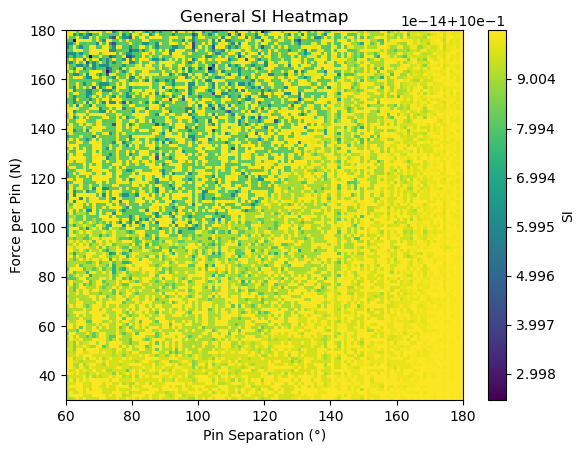

In [6]:
forces = np.linspace(30,180,120)
separations = np.linspace(60,180,120)
SI_grid = np.zeros((len(forces),len(separations)))
for i,F in enumerate(forces):
    for j,sep in enumerate(separations):
        angles = [0,(360-sep)/2,(360+sep)/2]
        SI_grid[i,j] = evaluate_clamp_basic([F,F,F], angles)['SI']

plt.imshow(SI_grid, origin='lower',
           extent=[separations[0],separations[-1],
                   forces[0],forces[-1]],
           cmap='viridis', aspect='auto')
plt.colorbar(label="SI")
plt.xlabel("Pin Separation (°)")
plt.ylabel("Force per Pin (N)")
plt.title("General SI Heatmap")
plt.show()


Scenario: Symmetric
  Stability index: 1.00, Classification: Stable


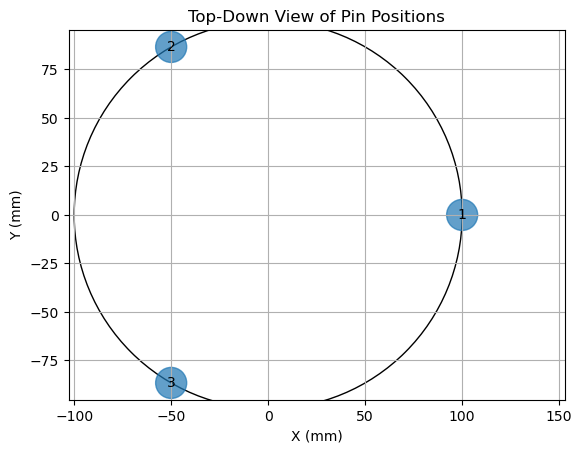

Scenario: Asymmetric force
  Stability index: 1.00, Classification: Stable


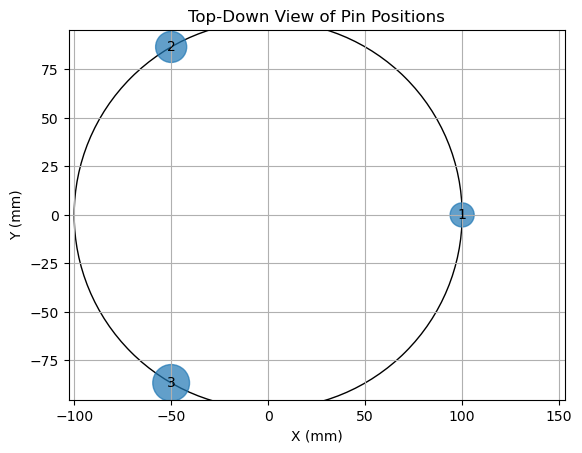

Scenario: Tilted pins
  Stability index: 0.96, Classification: Stable


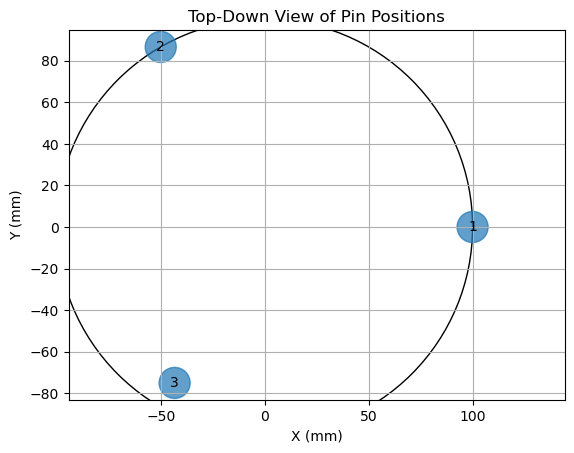

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def compute_lever_arms(latitudes, R):
    """
    Compute lever arm lengths for each pin based on latitude angles.
    latitudes: array of latitude angles in degrees (0=equator, positive towards north pole)
    R: skull radius
    Returns array of lever arms perpendicular to axis of potential rotation.
    """
    lat_rad = np.deg2rad(latitudes)
    return R * np.cos(lat_rad)

def compute_stability_index(forces, lever_arms):
    """
    Compute stability index = sum(F_i * r_i) / (sum(F_i) * R_max)
    where R_max = max lever arm (nominal radius).
    """
    total_force = np.sum(forces)
    if total_force == 0:
        return 0.0
    numerator = np.sum(forces * lever_arms)
    R_max = np.max(lever_arms)
    return numerator / (total_force * R_max)

def classify_stability(index):
    """
    Classify the stability index into qualitative categories.
    """
    if index > 0.9:
        return "Stable"
    elif index > 0.7:
        return "Marginal"
    else:
        return "Critical"

def plot_pin_setup(latitudes, longitudes, forces, R):
    """
    Plot a 2D top-down view of the skull and pin positions.
    latitudes: in degrees
    longitudes: in degrees
    forces: array of forces for marker sizes
    """
    lat_rad = np.deg2rad(latitudes)
    lon_rad = np.deg2rad(longitudes)
    x = R * np.cos(lat_rad) * np.cos(lon_rad)
    y = R * np.cos(lat_rad) * np.sin(lon_rad)
    
    plt.figure()
    circle = plt.Circle((0, 0), R, fill=False)
    plt.gca().add_artist(circle)
    plt.scatter(x, y, s=forces * 10, alpha=0.7)
    for i, (xi, yi) in enumerate(zip(x, y)):
        plt.text(xi, yi, f"{i+1}", ha='center', va='center')
    plt.title("Top-Down View of Pin Positions")
    plt.xlabel("X (mm)")
    plt.ylabel("Y (mm)")
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Example scenarios
R = 100  # Skull radius in mm
scenarios = [
    ("Symmetric", [0, 0, 0], [0, 120, 240], np.array([50, 50, 50])),
    ("Asymmetric force", [0, 0, 0], [0, 120, 240], np.array([30, 50, 70])),
    ("Tilted pins", [0, 0, 30], [0, 120, 240], np.array([50, 50, 50])),
]

for name, lats, lons, forces in scenarios:
    print(f"Scenario: {name}")
    lever_arms = compute_lever_arms(lats, R)
    idx = compute_stability_index(forces, lever_arms)
    cls = classify_stability(idx)
    print(f"  Stability index: {idx:.2f}, Classification: {cls}")
    plot_pin_setup(lats, lons, forces, R)



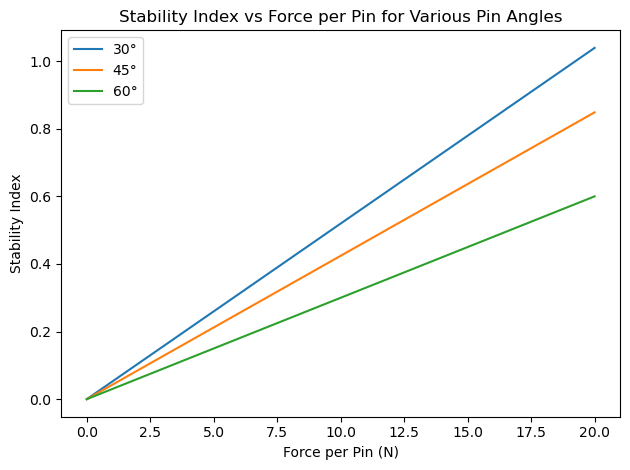

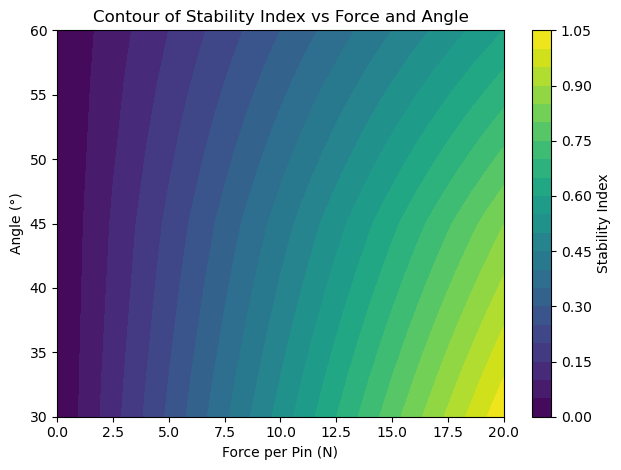

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import ace_tools as tools

# Define an angle-aware stability index function
def stability_index(F, theta_deg, R=0.1, mu=0.3):
    """
    Compute stability index for symmetric force on two pins at a given angle.
    M_resist = friction * total_force * effective lever arm
    effective lever arm = R * cos(theta)
    """
    theta = np.deg2rad(theta_deg)
    # total force is sum on both pins: 2*F
    M_resist = mu * (2 * F) * R * np.cos(theta)
    M_req = 1.0  # reference torque
    return M_resist / M_req

# Sweep force values and angles
forces = np.linspace(0, 20, 41)  # 0 to 20 N
angles = [30, 45, 60]  # degrees

# Prepare data for display
rows = []
for theta in angles:
    for F in forces:
        rows.append({
            "Force per Pin (N)": round(F, 1),
            "Angle (°)": theta,
            "Stability Index": round(stability_index(F, theta), 3)
        })
df = pd.DataFrame(rows)

# Show data table
#tools.display_dataframe_to_user(name="Stability Sweep: Force vs Angle", dataframe=df)

# Plot stability index vs force for each angle
plt.figure()
for theta in angles:
    idx = [stability_index(F, theta) for F in forces]
    plt.plot(forces, idx, label=f"{theta}°")
plt.xlabel("Force per Pin (N)")
plt.ylabel("Stability Index")
plt.title("Stability Index vs Force per Pin for Various Pin Angles")
plt.legend()
plt.tight_layout()
plt.show()

# Plot contours of stability index over force and angle grid
force_grid, angle_grid = np.meshgrid(forces, angles)
stability_grid = np.vectorize(stability_index)(force_grid, angle_grid)

plt.figure()
cp = plt.contourf(force_grid, angle_grid, stability_grid, levels=20)
plt.xlabel("Force per Pin (N)")
plt.ylabel("Angle (°)")
plt.title("Contour of Stability Index vs Force and Angle")
plt.colorbar(cp, label="Stability Index")
plt.tight_layout()
plt.show()


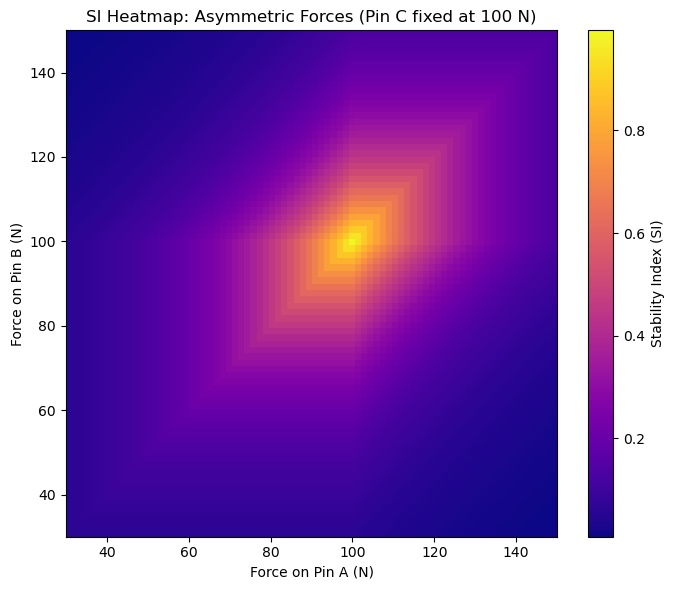

In [9]:
# Generate asymmetric force heatmap: Force on Pin A vs Force on Pin B (Pin C fixed)

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    phis = np.deg2rad(phis_deg)
    r = np.stack([skull_R*np.cos(phis),
                  skull_R*np.sin(phis),
                  np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    Mz = np.cross(r, F_vec)[:,2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    SI = np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)
    return SI

# Define parameter space
forces_A = np.linspace(30, 150, 80)
forces_B = np.linspace(30, 150, 80)
angles = [0, 120, 240]
force_C = 100

SI_asym = np.zeros((len(forces_A), len(forces_B)))

# Compute SI for each pair of force_A, force_B
for i, fA in enumerate(forces_A):
    for j, fB in enumerate(forces_B):
        SI_asym[j, i] = evaluate_clamp_basic([fA, fB, force_C], angles)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(SI_asym, origin='lower',
               extent=[forces_A[0], forces_A[-1], forces_B[0], forces_B[-1]],
               aspect='auto', cmap='plasma')
plt.colorbar(im, ax=ax, label="Stability Index (SI)")
ax.set_xlabel("Force on Pin A (N)")
ax.set_ylabel("Force on Pin B (N)")
ax.set_title("SI Heatmap: Asymmetric Forces (Pin C fixed at 100 N)")
plt.tight_layout()
plt.show()


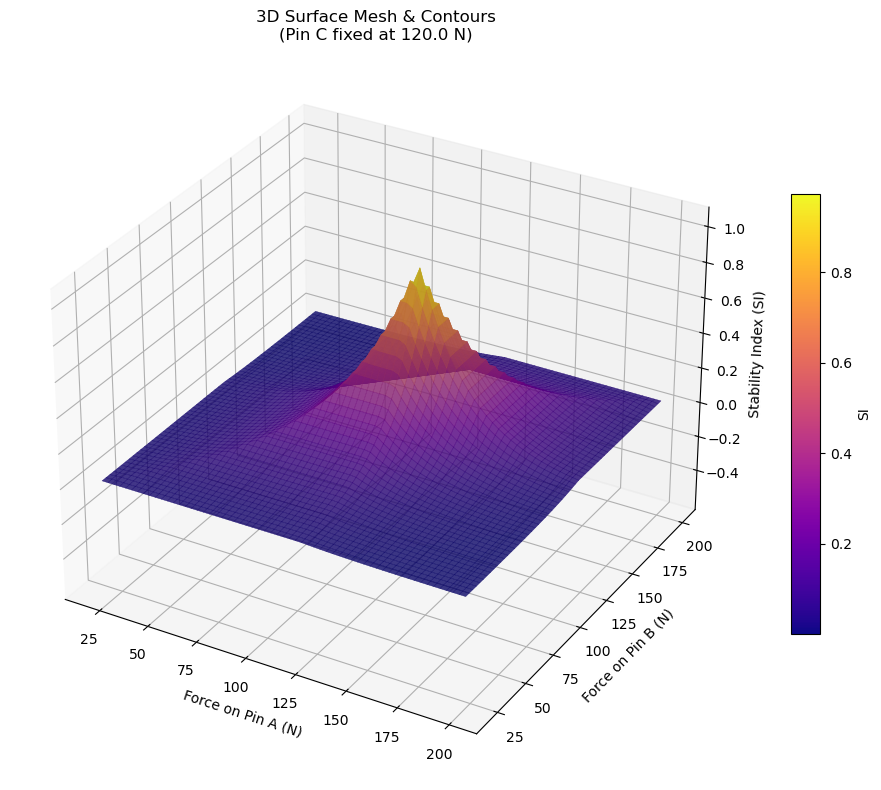

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    """
    Compute the Stability Index (SI) for a three-pin clamp
    given forces (N) and pin angles (degrees).
    """
    # convert pin angles to radians and compute pin position vectors
    phis = np.deg2rad(phis_deg)
    r = np.stack([
        skull_R * np.cos(phis),
        skull_R * np.sin(phis),
        np.zeros_like(phis)
    ], axis=1)                   # shape (3,3)
    
    # unit vectors from origin to each pin
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    
    # build force vectors, pointing inward
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    
    # resultant moment about z-axis
    Mz = np.cross(r, F_vec)[:, 2].sum()
    
    # penetration depths
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    
    # Stability Index: product of two exponentials
    SI = np.exp(-abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)
    return SI

if __name__ == "__main__":
    # pin angles in degrees
    angles = [0, 120, 240]

    # choose a 2D grid for forces on pins A and B
    force_min, force_max, N = 20, 200, 60
    fA = np.linspace(force_min, force_max, N)
    fB = np.linspace(force_min, force_max, N)
    FA, FB = np.meshgrid(fA, fB)

    # fix pin C at some value in the same range
    FC = 120.0

    # compute SI over the grid
    Z = np.zeros_like(FA)
    for i in range(N):
        for j in range(N):
            Z[i, j] = evaluate_clamp_basic([FA[i, j], FB[i, j], FC], angles)

    # normalize Z for coloring
    Z_min, Z_max = Z.min(), Z.max()
    norm_Z = (Z - Z_min) / (Z_max - Z_min)    # in [0,1]
    colors = plt.cm.plasma(norm_Z)

    # 3D plot setup
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1) filled surface with mesh lines
    surf = ax.plot_surface(
        FA, FB, Z,
        rstride=1, cstride=1,
        facecolors=colors,
        edgecolor='k', linewidth=0.3,
        antialiased=True,
        alpha=0.8
    )

    # 2) optional wireframe overlay (coarser mesh)
    # ax.plot_wireframe(
    #     FA, FB, Z,
    #     rstride=5, cstride=5,
    #     color='grey', linewidth=0.5
    # )

    # 3) contour lines projected onto the bottom plane
    # ax.contour(
    #     FA, FB, Z,
    #     zdir='z',
    #     offset=Z_min - 0.5,
    #     levels=10,
    #     cmap='plasma'
    # )

    # axes labels and title
    ax.set_xlabel('Force on Pin A (N)')
    ax.set_ylabel('Force on Pin B (N)')
    ax.set_zlabel('Stability Index (SI)')
    ax.set_title(f'3D Surface Mesh & Contours\n(Pin C fixed at {FC:.1f} N)')

    # set z-limits to make room for projected contours
    ax.set_zlim(Z_min - 0.6, Z_max + 0.1)

    # add a colorbar
    mappable = plt.cm.ScalarMappable(cmap='plasma')
    mappable.set_array(Z)
    fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=15, label='SI')

    plt.tight_layout()
    plt.show()


In [50]:
len(Z )

100

In [51]:
len(x )

100

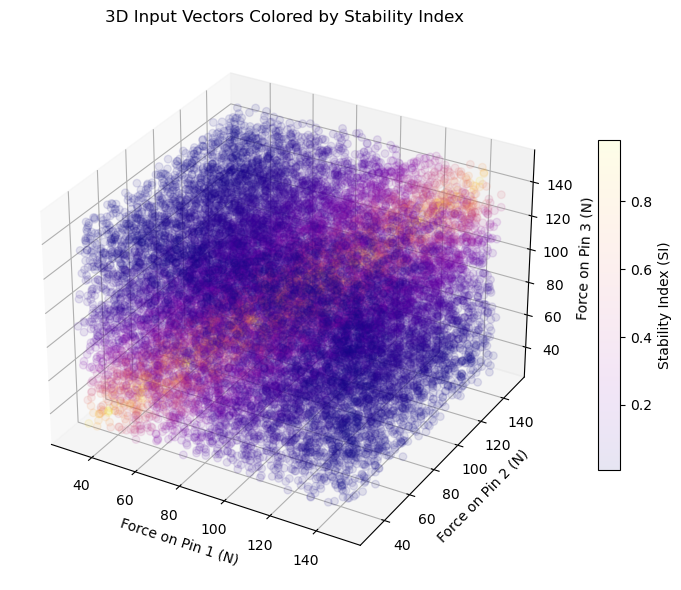

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

# Stability function
def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    phis = np.deg2rad(phis_deg)
    r = np.stack([
        skull_R * np.cos(phis),
        skull_R * np.sin(phis),
        np.zeros_like(phis)
    ], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    Mz = np.cross(r, F_vec)[:, 2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    return np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)

# Generate sample inputs
N = 20000
f_min, f_max = 30.0, 150.0
f1 = np.random.uniform(f_min, f_max, N)
f2 = np.random.uniform(f_min, f_max, N)
f3 = np.random.uniform(f_min, f_max, N)

# Compute SI for each sample
angles = [0, 120, 240]
SI = np.array([evaluate_clamp_basic([f1[i], f2[i], f3[i]], angles) for i in range(N)])

# Plot the 3D scatter, coloring by SI
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(f1, f2, f3, c=SI, cmap='plasma', marker='o', s=30, alpha=0.1)

# Colorbar for SI
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, aspect=15, label='Stability Index (SI)')

ax.set_xlabel('Force on Pin 1 (N)')
ax.set_ylabel('Force on Pin 2 (N)')
ax.set_zlabel('Force on Pin 3 (N)')
ax.set_title('3D Input Vectors Colored by Stability Index')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vectorized stability function for grid inputs
def SI_vec(F1, F2, F3, phis_deg=[0, 120, 240],
           skull_R=85.0, k_depth=0.04, Mcrit=50.0, dcrit=1.0):
    # pin positions
    phis = np.deg2rad(phis_deg)
    r = np.stack([skull_R * np.cos(phis),
                  skull_R * np.sin(phis),
                  np.zeros_like(phis)], axis=1)  # shape (3,3)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]  # shape (3,3)
    
    # stack forces into (M,N,3)
    F3_arr = np.full_like(F1, F3)  # ensure same shape
    F_stack = np.stack([F1, F2, F3_arr], axis=-1)  # shape (M,N,3)
    
    # compute force vectors for each pin: shape (3, M, N, 3)
    F_vec = np.array([
        -F_stack[..., i][..., None] * r_hat[i] for i in range(3)
    ])
    
    # moment about z at each gridpoint: sum over pins
    # r (3,3) and F_vec (3,M,N,3)
    M_vec = np.cross(r[:, None, None, :], F_vec)  # shape (3,M,N,3)
    Mz = M_vec[..., 2].sum(axis=0)  # shape (M, N)
    
    # penetration depths per pin: shape (3,M,N)
    depths = k_depth * np.abs((F_vec * r_hat[:, None, None, :]).sum(axis=-1))
    delta_d = depths.max(axis=0) - depths.min(axis=0)  # shape (M, N)
    
    return np.exp(-np.abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)

# --- analytic surface plot at F3 = constant ---
f_min, f_max, N = 30.0, 150.0, 200
f1 = np.linspace(f_min, f_max, N)
f2 = np.linspace(f_min, f_max, N)
F1, F2 = np.meshgrid(f1, f2)
F3_const = 100.0  # fixed pin 3 force

# evaluate stability index analytically on the grid
Z = SI_vec(F1, F2, F3_const)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    F1, F2, Z,
    cmap='plasma',
    edgecolor='k', linewidth=0.2,
    antialiased=True
)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, label='Stability Index (SI)')

ax.set_xlabel('Force on Pin 1 (N)')
ax.set_ylabel('Force on Pin 2 (N)')
ax.set_zlabel('Stability Index (SI)')
ax.set_title(f'Analytic SI Surface at Pin 3 = {F3_const:.1f} N')

plt.tight_layout()
plt.show()


NameError: name 'Mz' is not defined

In [45]:
f3_vals

array([30.])

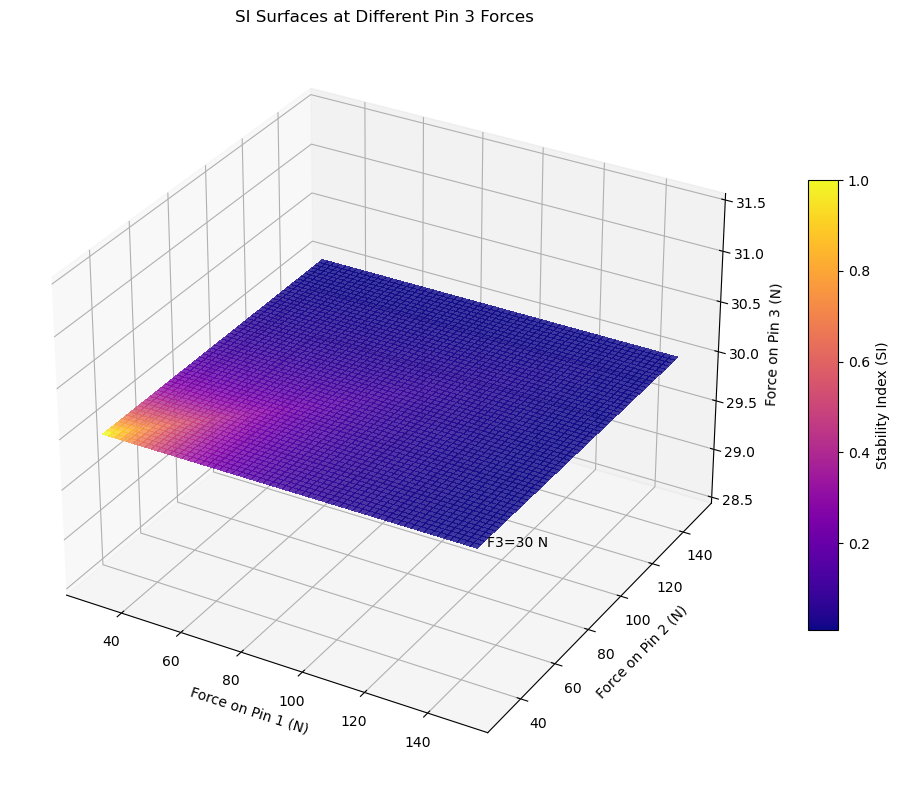

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # registers 3D projection

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    phis = np.deg2rad(phis_deg)
    r = np.stack([
        skull_R * np.cos(phis),
        skull_R * np.sin(phis),
        np.zeros_like(phis)
    ], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    Mz = np.cross(r, F_vec)[:, 2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    return np.exp(-abs(Mz)/Mcrit) * np.exp(-delta_d/dcrit)

if __name__ == "__main__":
    # Pin angles
    angles = [0, 120, 240]

    # Grid for Pin 1 (F1) and Pin 2 (F2)
    N = 60
    f_min, f_max = 30.0, 150.0
    f1 = np.linspace(f_min, f_max, N)
    f2 = np.linspace(f_min, f_max, N)
    F1, F2 = np.meshgrid(f1, f2)

    # Choose several values for Pin 3 (F3)
    num_slices = 1
    f3_vals = np.linspace(f_min, f_max, num_slices)

    # Compute SI for each (F1, F2) at each F3 slice
    SI_slices = np.zeros((num_slices, N, N))
    for k, f3 in enumerate(f3_vals):
        for i in range(N):
            for j in range(N):
                SI_slices[k, i, j] = evaluate_clamp_basic(
                    [F1[i, j], F2[i, j], f3], angles
                )

    # Normalize SI for colormap
    vmin, vmax = SI_slices.min(), SI_slices.max()
    norm = plt.Normalize(vmin, vmax)
    cmap = plt.cm.plasma

    # Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for k, f3 in enumerate(f3_vals):
        Z = np.full_like(F1, f3)              # Z-axis = force on Pin 3
        facecolors = cmap(norm(SI_slices[k])) # color = SI
        ax.plot_surface(
            F1, F2, Z,
            rstride=1, cstride=1,
            facecolors=facecolors,
            shade=False,
            linewidth=0,
            antialiased=False,
            alpha=0.8
        )
        # Label each slice with its F3 value
        ax.text(f_max + 2, f_min + 2, f3,
                f"F3={f3:.0f} N",
                color='k')

    # Colorbar for SI
    m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    m.set_array([])
    fig.colorbar(m, ax=ax, shrink=0.6, aspect=15,
                 label='Stability Index (SI)')

    # Axes labels & title
    ax.set_xlabel('Force on Pin 1 (N)')
    ax.set_ylabel('Force on Pin 2 (N)')
    ax.set_zlabel('Force on Pin 3 (N)')
    ax.set_title('SI Surfaces at Different Pin 3 Forces')

    plt.tight_layout()
    plt.show()


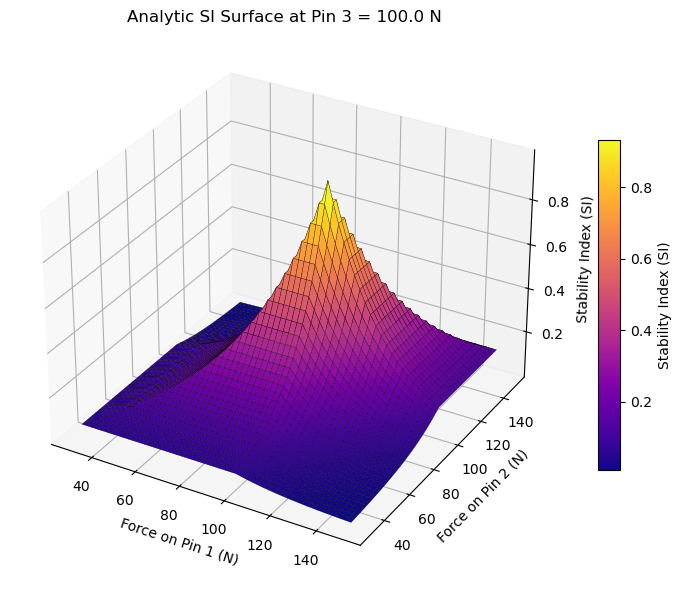

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vectorized stability function for grid inputs
def SI_vec(F1, F2, F3, phis_deg=[0, 120, 240],
           skull_R=85.0, k_depth=0.04, Mcrit=50.0, dcrit=1.0):
    # pin positions
    phis = np.deg2rad(phis_deg)
    r = np.stack([skull_R * np.cos(phis),
                  skull_R * np.sin(phis),
                  np.zeros_like(phis)], axis=1)  # shape (3,3)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]  # shape (3,3)
    
    # stack forces into (M,N,3)
    F3_arr = np.full_like(F1, F3)  # ensure same shape
    F_stack = np.stack([F1, F2, F3_arr], axis=-1)  # shape (M,N,3)
    
    # compute force vectors for each pin: shape (3, M, N, 3)
    F_vec = np.array([
        -F_stack[..., i][..., None] * r_hat[i] for i in range(3)
    ])
    
    # moment about z at each gridpoint: sum over pins
    # r (3,3) and F_vec (3,M,N,3)
    M_vec = np.cross(r[:, None, None, :], F_vec)  # shape (3,M,N,3)
    Mz = M_vec[..., 2].sum(axis=0)  # shape (M, N)
    
    # penetration depths per pin: shape (3,M,N)
    depths = k_depth * np.abs((F_vec * r_hat[:, None, None, :]).sum(axis=-1))
    delta_d = depths.max(axis=0) - depths.min(axis=0)  # shape (M, N)
    
    return np.exp(-np.abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)

# --- analytic surface plot at F3 = constant ---
f_min, f_max, N = 30.0, 150.0, 200
f1 = np.linspace(f_min, f_max, N)
f2 = np.linspace(f_min, f_max, N)
F1, F2 = np.meshgrid(f1, f2)
F3_const = 100.0  # fixed pin 3 force

# evaluate stability index analytically on the grid
Z = SI_vec(F1, F2, F3_const)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    F1, F2, Z,
    cmap='plasma',
    edgecolor='k', linewidth=0.2,
    antialiased=True
)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, label='Stability Index (SI)')

ax.set_xlabel('Force on Pin 1 (N)')
ax.set_ylabel('Force on Pin 2 (N)')
ax.set_zlabel('Stability Index (SI)')
ax.set_title(f'Analytic SI Surface at Pin 3 = {F3_const:.1f} N')

plt.tight_layout()
plt.show()


C:\Users\hamed\AppData\Local\Temp\ipykernel_19652\3122159476.py:53: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



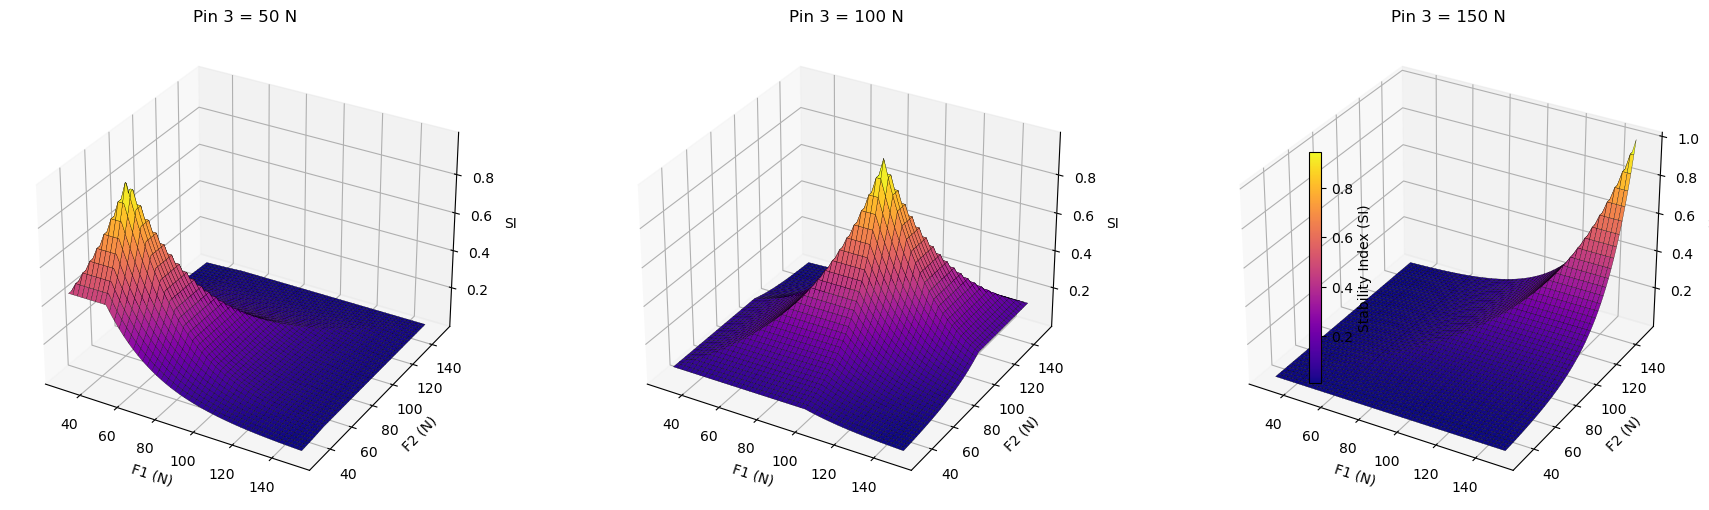

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vectorized stability function (as defined earlier)
def SI_vec(F1, F2, F3, phis_deg=[0, 120, 240],
           skull_R=85.0, k_depth=0.04, Mcrit=50.0, dcrit=1.0):
    phis = np.deg2rad(phis_deg)
    r = np.stack([skull_R * np.cos(phis),
                  skull_R * np.sin(phis),
                  np.zeros_like(phis)], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    F3_arr = np.full_like(F1, F3)
    F_stack = np.stack([F1, F2, F3_arr], axis=-1)
    F_vec = np.array([
        -F_stack[..., i][..., None] * r_hat[i] for i in range(3)
    ])
    M_vec = np.cross(r[:, None, None, :], F_vec)
    Mz = M_vec[..., 2].sum(axis=0)
    depths = k_depth * np.abs((F_vec * r_hat[:, None, None, :]).sum(axis=-1))
    delta_d = depths.max(axis=0) - depths.min(axis=0)
    return np.exp(-np.abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)

# Grid for F1 and F2
f_min, f_max, N = 30.0, 150.0, 200
f1 = np.linspace(f_min, f_max, N)
f2 = np.linspace(f_min, f_max, N)
F1, F2 = np.meshgrid(f1, f2)

# Choose multiple F3 values
f3_values = [50.0, 100.0, 150.0]

# Create subplots
fig = plt.figure(figsize=(18, 5))
for idx, f3_val in enumerate(f3_values, start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    Z = SI_vec(F1, F2, f3_val)
    surf = ax.plot_surface(
        F1, F2, Z,
        cmap='plasma',
        edgecolor='k', linewidth=0.2,
        antialiased=True
    )
    ax.set_title(f'Pin 3 = {f3_val:.0f} N')
    ax.set_xlabel('F1 (N)')
    ax.set_ylabel('F2 (N)')
    ax.set_zlabel('SI')

# Shared colorbar
cbar = fig.colorbar(surf, ax=fig.get_axes(), shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Stability Index (SI)')

plt.tight_layout()
plt.show()


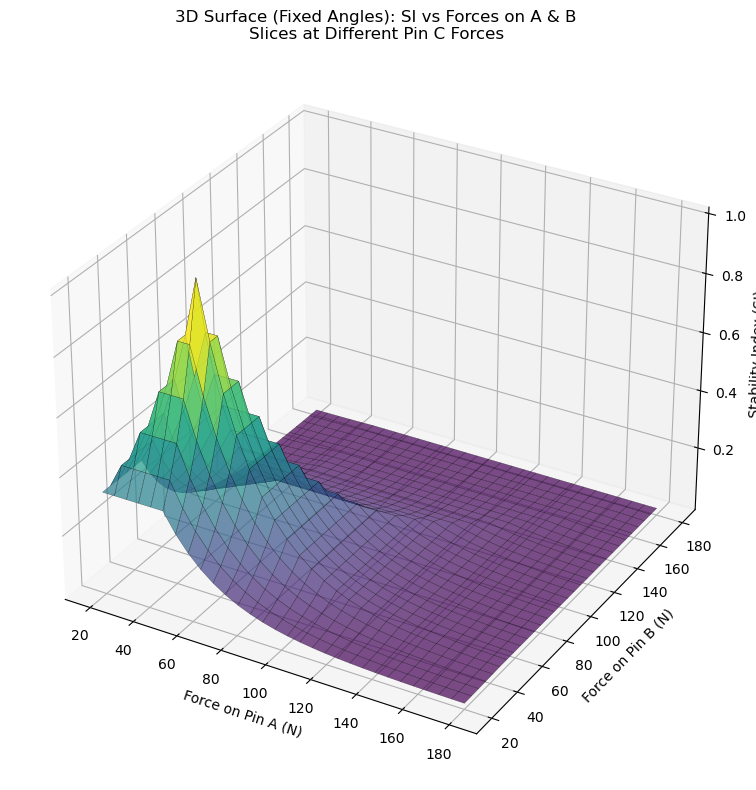

In [ ]:
# Use 3D surface plotting on slices instead of scatter
from mpl_toolkits.mplot3d import Axes3D

# Wider range and higher resolution
force_vals = np.linspace(20, 180, 30)
n = len(force_vals)
SI_grid = np.zeros((n, n, n))

# Fill the 3D SI grid
for i, F1 in enumerate(force_vals):
    for j, F2 in enumerate(force_vals):
        for k, F3 in enumerate(force_vals):
            SI_grid[i, j, k] = stability_index([F1, F2, F3])

# Visualize surface slices at selected F3 (Pin C) indices
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

slice_indices = [5, 15, 25]  # Low, mid, high values for Pin C
for idx in slice_indices:
    F1g, F2g = np.meshgrid(force_vals, force_vals, indexing='ij')
    Z = SI_grid[:, :, idx]
    ax.plot_surface(F1g, F2g, Z,
                    label=f"F3={force_vals[idx]:.0f} N",
                    alpha=0.7, cmap='viridis', edgecolor='k', linewidth=0.2)

ax.set_xlabel("Force on Pin A (N)")
ax.set_ylabel("Force on Pin B (N)")
ax.set_zlabel("Stability Index (SI)")
ax.set_title("3D Surface: SI vs Forces on Pin A & B\n(Slices at Different Pin C Forces)")
plt.tight_layout()
plt.show()


C:\Users\hamed\AppData\Local\Temp\ipykernel_19652\916278748.py:57: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



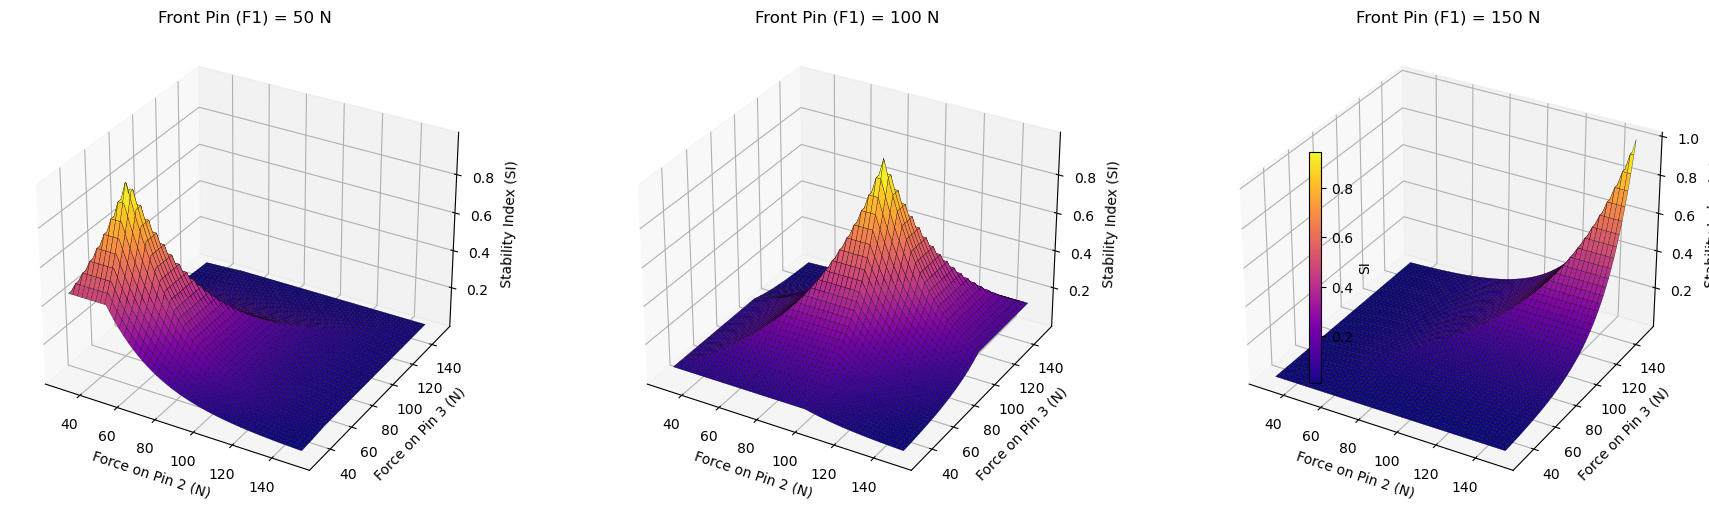

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vectorized stability function
def SI_vec(F1, F2, F3, phis_deg=[0, 120, 240],
           skull_R=85.0, k_depth=0.04, Mcrit=50.0, dcrit=1.0):
    phis = np.deg2rad(phis_deg)
    r = np.stack([skull_R * np.cos(phis),
                  skull_R * np.sin(phis),
                  np.zeros_like(phis)], axis=1)  # shape (3,3)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]  # shape (3,3)
    
    # ensure F1 has same shape
    F1_arr = np.full_like(F2, F1)
    F_stack = np.stack([F1_arr, F2, F3], axis=-1)  # shape (M,N,3)
    
    # compute force vectors for each pin
    F_vec = np.array([ -F_stack[..., i][..., None] * r_hat[i] for i in range(3) ])
    # moment about z
    M_vec = np.cross(r[:, None, None, :], F_vec)
    Mz = M_vec[..., 2].sum(axis=0)
    # penetration depths
    depths = k_depth * np.abs((F_vec * r_hat[:, None, None, :]).sum(axis=-1))
    delta_d = depths.max(axis=0) - depths.min(axis=0)
    return np.exp(-np.abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)

# Grid for F2 and F3 (rear pins)
f_min, f_max, N = 30.0, 150.0, 200
f2 = np.linspace(f_min, f_max, N)
f3 = np.linspace(f_min, f_max, N)
F2, F3 = np.meshgrid(f2, f3)

# Multiple front pin (F1) preloads
f1_values = [50.0, 100.0, 150.0]

# Plot analytic SI surfaces for each F1 preload
fig = plt.figure(figsize=(18, 5))
for idx, f1_val in enumerate(f1_values, start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    Z = SI_vec(f1_val, F2, F3)
    surf = ax.plot_surface(
        F2, F3, Z,
        cmap='plasma',
        edgecolor='k', linewidth=0.2,
        antialiased=True
    )
    ax.set_title(f'Front Pin (F1) = {f1_val:.0f} N')
    ax.set_xlabel('Force on Pin 2 (N)')
    ax.set_ylabel('Force on Pin 3 (N)')
    ax.set_zlabel('Stability Index (SI)')

# Shared colorbar
cbar = fig.colorbar(surf, ax=fig.get_axes(), shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('SI')

plt.tight_layout()
plt.show()


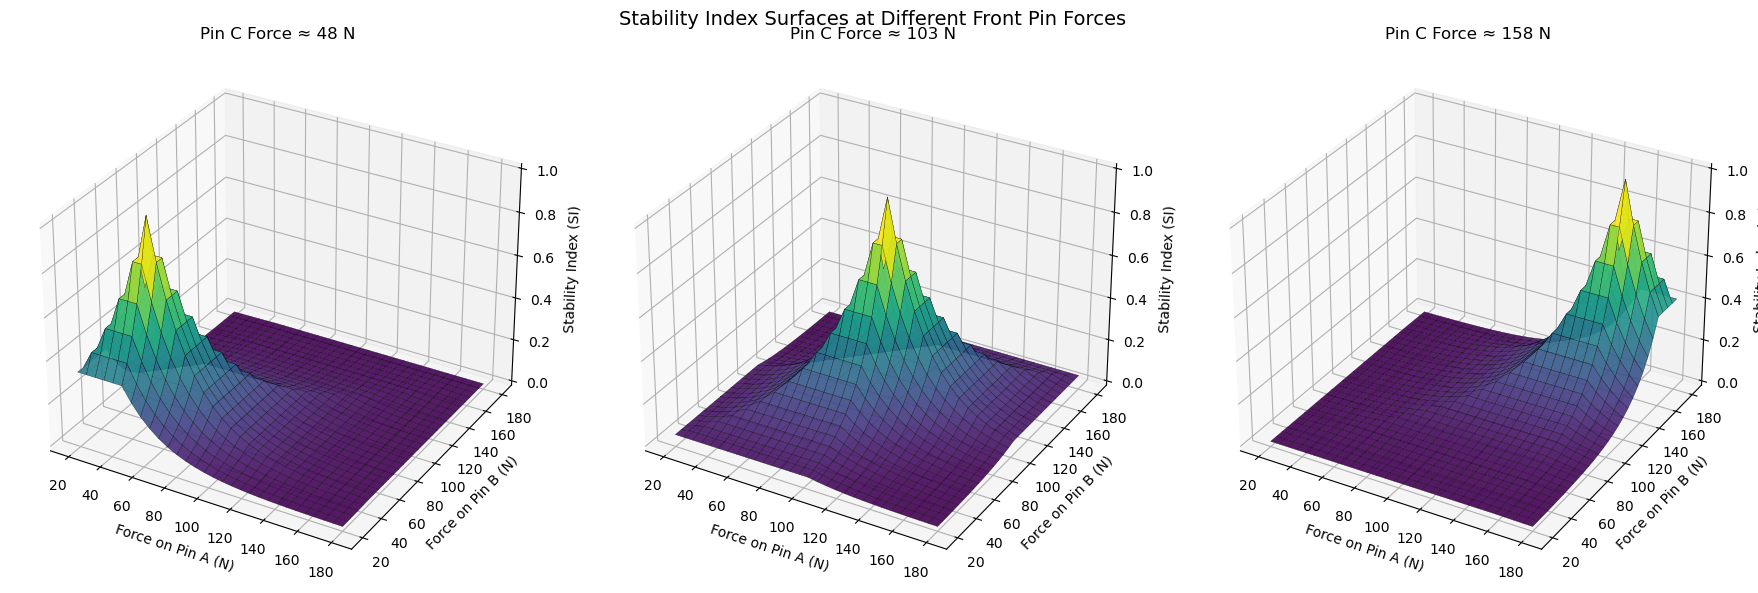

In [71]:
# Plot each slice in its own subplot for clearer comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})

slice_indices = [5, 15, 25]  # Corresponds to ~40N, 100N, 160N for Pin C
titles = [f"Pin C Force ≈ {force_vals[idx]:.0f} N" for idx in slice_indices]

for ax, idx, title in zip(axes, slice_indices, titles):
    F1g, F2g = np.meshgrid(force_vals, force_vals, indexing='ij')
    Z = SI_grid[:, :, idx]
    surf = ax.plot_surface(F1g, F2g, Z, cmap='viridis', edgecolor='k', linewidth=0.2, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Force on Pin A (N)")
    ax.set_ylabel("Force on Pin B (N)")
    ax.set_zlabel("Stability Index (SI)")
    ax.set_zlim(0, 1)

fig.suptitle("Stability Index Surfaces at Different Front Pin Forces", fontsize=14)
plt.tight_layout()
plt.show()


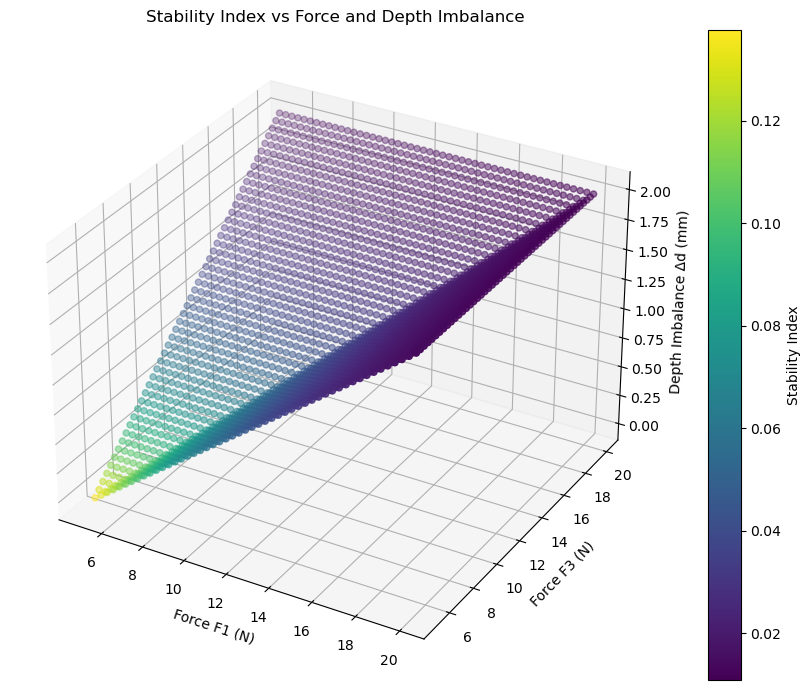

In [ ]:
# Updated 3D plot: Z-axis shows delta_d (depth imbalance), color shows Stability Index
import numpy as np
import matplotlib.pyplot as plt

# Updated function
def evaluate_clamp_with_depth(forces, angles_deg, depths_mm, R=0.085, mu=0.3, Mcrit=1.0, dcrit=1.0):
    thetas = np.deg2rad(angles_deg)
    M_resist = mu * R * sum(f * np.cos(t) for f, t in zip(forces, thetas))
    delta_d = np.ptp(depths_mm)
    SI = np.exp(-abs(M_resist)/Mcrit) * np.exp(-delta_d/dcrit)
    return SI, delta_d

# Simulation parameters
F_vals = np.linspace(5, 20, 50)
D_vals = np.linspace(0.5, 2.5, 50)
angles = [45, 45, 45]

# Generate force grid
F1, F3 = np.meshgrid(F_vals, F_vals)
F1_flat, F3_flat = F1.flatten(), F3.flatten()
F2_fixed = 10

# Generate diverse depth combinations
depth_combinations = [
    [d1, d2, d3]
    for d1 in D_vals
    for d2 in D_vals
    for d3 in D_vals
]
selected_depths = depth_combinations[::len(depth_combinations)//len(F1_flat)]

# Compute SI and delta_d
stabilities, delta_ds = [], []
for f1, f3, depths in zip(F1_flat, F3_flat, selected_depths):
    si, dd = evaluate_clamp_with_depth([f1, F2_fixed, f3], angles, depths)
    stabilities.append(si)
    delta_ds.append(dd)

# 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F1_flat, F3_flat, delta_ds, c=stabilities, cmap='viridis')
ax.set_xlabel('Force F1 (N)')
ax.set_ylabel('Force F3 (N)')
ax.set_zlabel('Depth Imbalance Δd (mm)')
fig.colorbar(sc, label='Stability Index')
plt.title('Stability Index vs Force and Depth Imbalance')
plt.tight_layout()
plt.show()


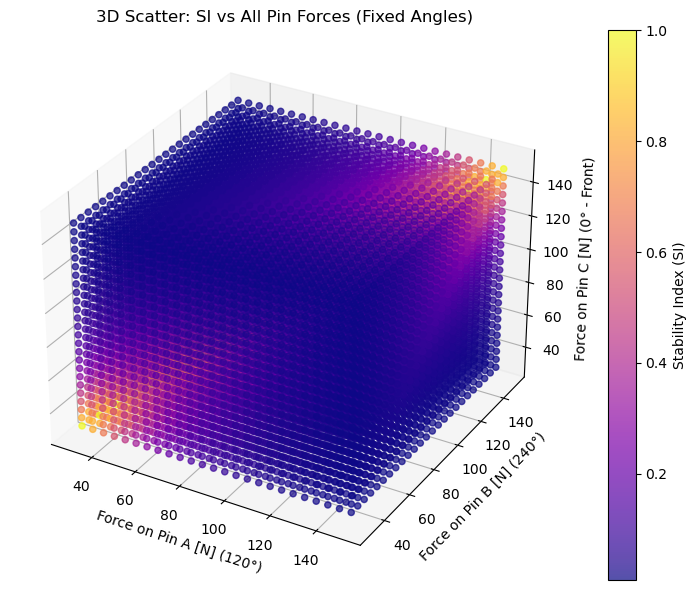

In [27]:
# 3D scatter plot: Vary F_A, F_B, F_C independently
forces = np.linspace(30, 150, 25)
phis = [0, 120, 240]  # fixed symmetric pin placement

F_A_vals, F_B_vals, F_C_vals, SI_vals = [], [], [], []

# Sweep over all combinations of F_A, F_B, F_C
for FA in forces:
    for FB in forces:
        for FC in forces:
            SI = evaluate_clamp_basic([FA, FB, FC], phis)
            F_A_vals.append(FA)
            F_B_vals.append(FB)
            F_C_vals.append(FC)
            SI_vals.append(SI)

# 3D scatter plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F_A_vals, F_B_vals, F_C_vals, c=SI_vals, cmap='plasma', alpha=0.7)
cbar = fig.colorbar(sc, ax=ax, label="Stability Index (SI)")
ax.set_xlabel("Force on Pin A [N] (120°)")
ax.set_ylabel("Force on Pin B [N] (240°)")
ax.set_zlabel("Force on Pin C [N] (0° - Front)")
ax.set_title("3D Scatter: SI vs All Pin Forces (Fixed Angles)")
plt.tight_layout()
plt.show()


In [17]:
force_values

array([ 0.,  5., 10., 15., 20.])

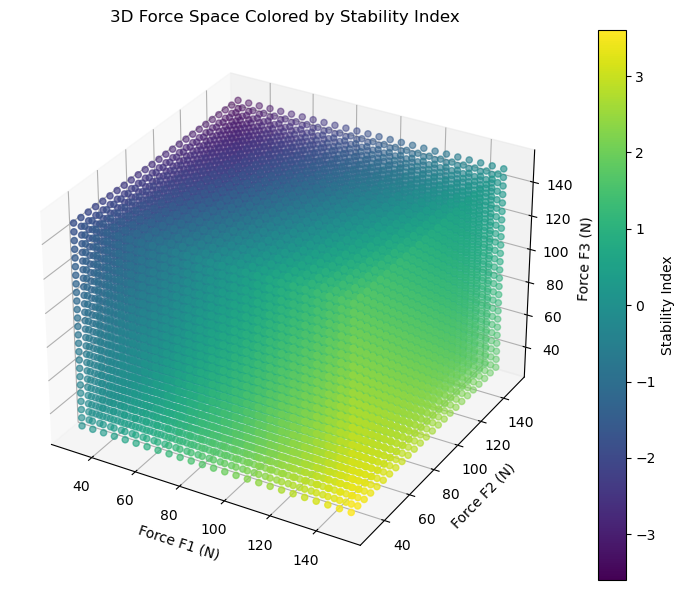

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3-pin stability function
def stability_index_3pin(forces, angles_deg, R=0.1, mu=0.3):
    thetas = np.deg2rad(angles_deg)
    M_resist = mu * R * sum(f * np.cos(t) for f, t in zip(forces, thetas))
    return M_resist

# Define grid of forces
force_values = np.linspace(30, 150, 25)  # 5 values: 0, 5, 10, 15, 20 N
angles = [45, 45, 45]  # fixed pin angles
angles =[0, 120, 240] 

# Generate all combinations of F1, F2, F3
F1, F2, F3 = np.meshgrid(force_values, force_values, force_values)
F1_flat = F1.flatten()
F2_flat = F2.flatten()
F3_flat = F3.flatten()

# Compute stability for each combination
stability = np.array([
    stability_index_3pin([f1, f2, f3], angles)
    for f1, f2, f3 in zip(F1_flat, F2_flat, F3_flat)
])

# 3D Scatter plot with stability as color
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(F1_flat, F2_flat, F3_flat, c=stability)
ax.set_xlabel('Force F1 (N)')
ax.set_ylabel('Force F2 (N)')
ax.set_zlabel('Force F3 (N)')
plt.title('3D Force Space Colored by Stability Index')
fig.colorbar(sc, label='Stability Index')
plt.tight_layout()
plt.show()


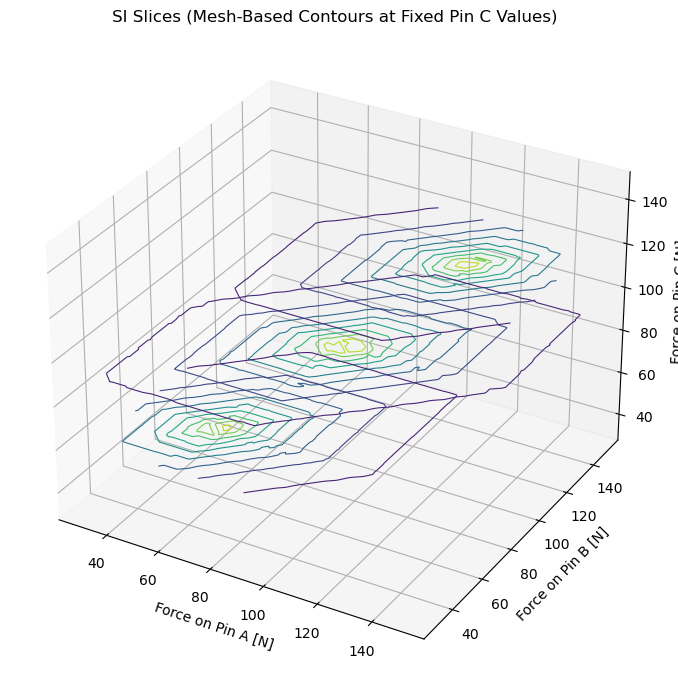

In [24]:
from scipy.interpolate import griddata

# Downsampled grid for meshplot feasibility
forces = np.linspace(30, 150, 20)
angles = [0, 120, 240]
points = []
si_values = []

# Sweep all combinations (FA, FB, FC)
for FA in forces:
    for FB in forces:
        for FC in forces:
            SI = evaluate_clamp_basic([FA, FB, FC], angles)
            points.append([FA, FB, FC])
            si_values.append(SI)

points = np.array(points)
si_values = np.array(si_values)

# Interpolate to a 3D mesh grid
FA_grid, FB_grid, FC_grid = np.meshgrid(
    np.linspace(30, 150, 200),
    np.linspace(30, 150, 200),
    np.linspace(30, 150, 200)
)
SI_grid = griddata(points, si_values, (FA_grid, FB_grid, FC_grid), method='linear')

# Plot iso-surfaces (contour-like) using slices
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Add several iso-surface-like slices manually
for fC_fixed in [60, 90, 120]:
    idx = np.abs(FC_grid[0, 0, :] - fC_fixed).argmin()
    si_slice = SI_grid[:, :, idx]
    ax.contour(FA_grid[:, :, idx], FB_grid[:, :, idx], si_slice,
               levels=10, cmap='viridis', linewidths=0.8, linestyles='solid', offset=fC_fixed)

ax.set_xlabel("Force on Pin A [N]")
ax.set_ylabel("Force on Pin B [N]")
ax.set_zlabel("Force on Pin C [N]")
ax.set_title("SI Slices (Mesh-Based Contours at Fixed Pin C Values)")
ax.set_zlim(30, 150)
plt.tight_layout()
plt.show()
